<a href="https://colab.research.google.com/github/RAVIAPTISWETHA/Predictive-Insights-into-Global-Hiring-and-Layoff-Trends/blob/main/Predictive_Insights_into_Global_Hiring_and_Layoff_Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **INSTALLING LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **DATA LOADING**

In [4]:
df = pd.read_csv(r'/content/drive/My Drive/new project/global_layoffs_2020_2026.csv')
print(f"Raw data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Raw data loaded: 15,000 rows × 18 columns


## **CLEANING & PREPROCESSING**

In [5]:
df = df.drop_duplicates()
df['layoff_date'] = pd.to_datetime(df['layoff_date'], errors='coerce')
df['layoff_count'] = pd.to_numeric(df['layoff_count'], errors='coerce').fillna(0).astype(int)
df['ai_automation_flag'] = pd.to_numeric(df['ai_automation_flag'], errors='coerce').fillna(0).astype(int)
df['year'] = df['layoff_date'].dt.year
df['ai_layoff_count'] = df['layoff_count'] * df['ai_automation_flag']

df.to_csv('cleaned_global_layoffs_2020_2026.csv', index=False)
print("Cleaned file saved as: cleaned_global_layoffs_2020_2026.csv")

Cleaned file saved as: cleaned_global_layoffs_2020_2026.csv


## **Exploratory Data Analysis (EDA)**

In [6]:
print("\nPERFORMING EXPLORATORY DATA ANALYSIS (EDA)...")
print("\n--- 1. Dataset Overview ---")
print(f"Rows after cleaning: {df.shape[0]:,}")
print(f"Columns: {list(df.columns)}")
print(df.info())


PERFORMING EXPLORATORY DATA ANALYSIS (EDA)...

--- 1. Dataset Overview ---
Rows after cleaning: 15,000
Columns: ['company', 'industry', 'country', 'continent', 'layoff_date', 'layoff_count', 'workforce_percentage', 'funding_stage', 'total_funding_million_usd', 'stock_price_change_7d', 'hiring_status', 'reason', 'revenue_growth_percent', 'market_cap_billion_usd', 'company_size', 'layoff_severity_score', 'ai_automation_flag', 'economic_cycle_flag', 'year', 'ai_layoff_count']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   company                    15000 non-null  object        
 1   industry                   15000 non-null  object        
 2   country                    15000 non-null  object        
 3   continent                  15000 non-null  object        
 4   layoff_date                15

## **Plot: Distribution of Layoff Counts**

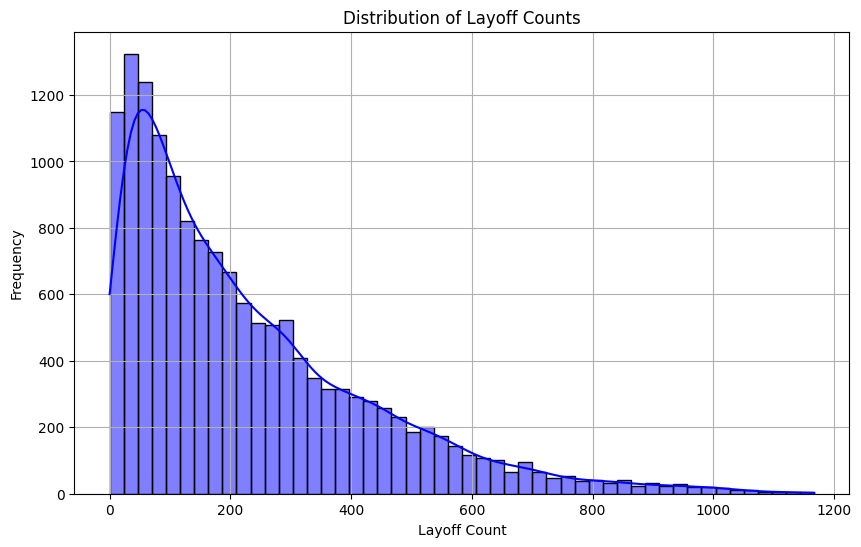


--- Missing Values ---
No missing values!


In [24]:
plt.figure(figsize=(10,6))
sns.histplot(df['layoff_count'], bins=50, kde=True, color='blue')
plt.title('Distribution of Layoff Counts')
plt.xlabel('Layoff Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

## Plot: Missing Values Bar Plot (if any)

In [8]:
if missing.sum() > 0:
    plt.figure(figsize=(10,6))
    missing[missing > 0].plot(kind='bar', color='salmon')
    plt.title('Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Missing Count')
    plt.grid(True)
    plt.show()
else:
    print("No missing values to plot.")

No missing values to plot.


## **AI vs Non-AI breakdown**

In [9]:
ai_total = df['ai_layoff_count'].sum()
non_ai_total = df['layoff_count'].sum() - ai_total
print("\n--- AI vs Non-AI Layoffs ---")
print(f"AI-related layoffs     : {ai_total:,.0f} people")
print(f"Non-AI layoffs         : {non_ai_total:,.0f} people")
print(f"AI share               : {ai_total / df['layoff_count'].sum() * 100:.1f}%")


--- AI vs Non-AI Layoffs ---
AI-related layoffs     : 560,231 people
Non-AI layoffs         : 2,861,504 people
AI share               : 16.4%


## **Plot: Pie Chart for AI vs Non-AI Layoffs**

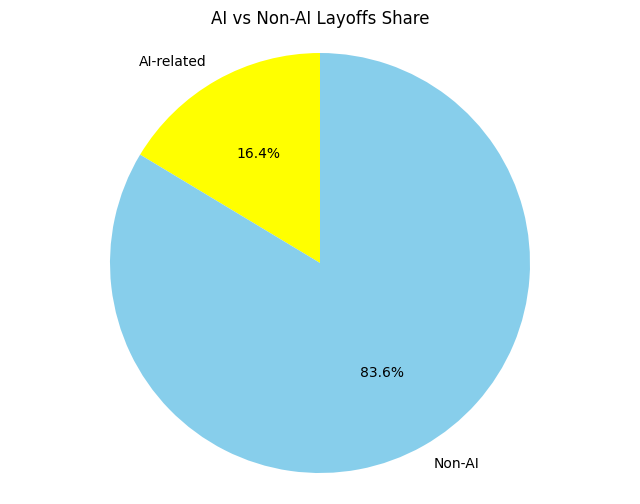

In [12]:
plt.figure(figsize=(8,6))
labels = ['AI-related', 'Non-AI']
sizes = [ai_total, non_ai_total]
colors = ['yellow','skyblue']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('AI vs Non-AI Layoffs Share')
plt.axis('equal')
plt.show()

## Top Catogories

In [19]:
top_industries = df.groupby('industry')['layoff_count'].sum().nlargest(5)
print("\n--- Top 5 Industries (overall) ---")
print(top_industries)


--- Top 5 Industries (overall) ---
industry
Energy     391285
Finance    391075
Tech       390703
FinTech    385037
EdTech     384424
Name: layoff_count, dtype: int64


## **Plot: Bar Plot for Top Industries**

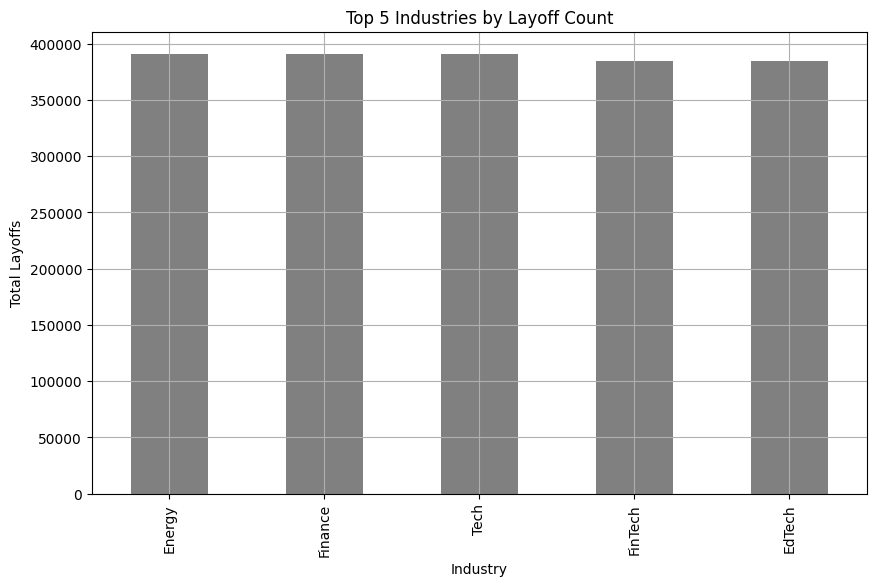

In [25]:
plt.figure(figsize=(10,6))
top_industries.plot(kind='bar', color='grey')
plt.title('Top 5 Industries by Layoff Count')
plt.xlabel('Industry')
plt.ylabel('Total Layoffs')
plt.grid(True)
plt.show()